# 01 - Análise Exploratória de Dados (EDA)

Investigação do dataset de risco de crédito: distribuições, correlações, balanceamento da variável-alvo (inadimplência) e formulação de hipóteses iniciais.

**Objetivo:** entender os dados, levantar problemas de qualidade (ausentes, outliers) e gerar as decisões que vão guiar a etapa de limpeza/preparação (`02_preprocessing`) e a modelagem (`03_modeling`).

## 1. Setup

Imports, configuração de estilo dos gráficos e carregamento do dataset bruto via `src.data.load_raw_data`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Raiz do projeto (um nível acima de notebooks/), para importar o pacote src
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_raw_data

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12

# Carrega o dataset bruto
df = load_raw_data(PROJECT_ROOT / "data/raw/credit_risk_dataset.csv")
print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dataset carregado: 32581 linhas x 12 colunas


### Dicionário das variáveis

| Coluna | Significado |
|---|---|
| `person_age` | Idade do cliente |
| `person_income` | Renda anual |
| `person_home_ownership` | Tipo de moradia (RENT, OWN, MORTGAGE, OTHER) |
| `person_emp_length` | Tempo de emprego (anos) |
| `loan_intent` | Finalidade do empréstimo |
| `loan_grade` | Nota de risco do empréstimo (A a G) |
| `loan_amnt` | Valor do empréstimo |
| `loan_int_rate` | Taxa de juros |
| `loan_status` | **ALVO** — 1 = inadimplente, 0 = adimplente |
| `loan_percent_income` | Razão empréstimo / renda |
| `cb_person_default_on_file` | Já teve calote no histórico (Y/N) |
| `cb_person_cred_hist_length` | Tempo de histórico de crédito (anos) |

## 2. Visão geral dos dados

In [2]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Tipos das colunas e memória
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [4]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [5]:
# Estatísticas das variáveis categóricas
df.describe(include="object").T

/tmp/ipykernel_37010/1308008430.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [6]:
# Linhas duplicadas
n_dup = df.duplicated().sum()
print(f"Linhas duplicadas: {n_dup} ({n_dup / len(df):.2%})")

Linhas duplicadas: 165 (0.51%)


## 3. Qualidade dos dados — valores ausentes

In [7]:
# Contagem e percentual de ausentes por coluna
ausentes = df.isna().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)
tabela_ausentes = pd.DataFrame({
    "qtd_ausentes": ausentes,
    "pct_ausentes": (ausentes / len(df) * 100).round(2),
})
tabela_ausentes

,qtd_ausentes,pct_ausentes
loan_int_rate,3116,9.56
person_emp_length,895,2.75


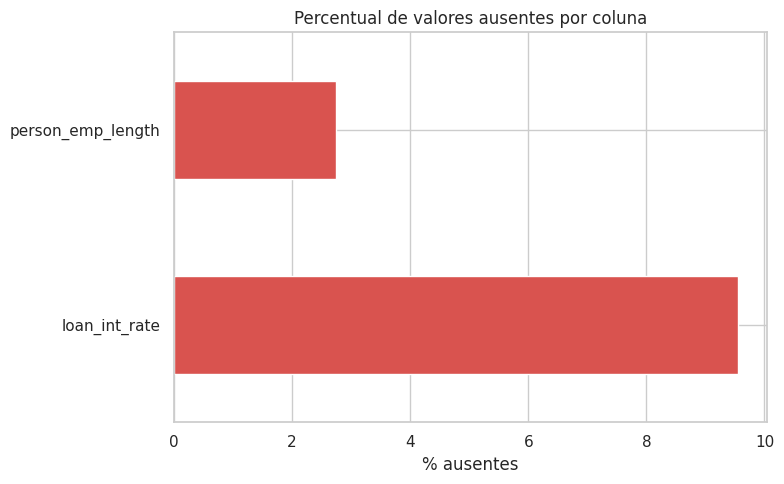

In [8]:
# Gráfico do percentual de ausentes
if not tabela_ausentes.empty:
    ax = tabela_ausentes["pct_ausentes"].plot(kind="barh", color="#d9534f")
    ax.set_title("Percentual de valores ausentes por coluna")
    ax.set_xlabel("% ausentes")
    plt.tight_layout()
    plt.show()
else:
    print("Sem valores ausentes.")

## 4. Variável-alvo: `loan_status`

Verificamos o balanceamento entre adimplentes (0) e inadimplentes (1) — fundamental para escolher métricas e técnicas de modelagem.

Contagem:
 loan_status
0    25473
1     7108
Name: count, dtype: int64 

Proporção:
 loan_status
0    0.7818
1    0.2182
Name: proportion, dtype: float64


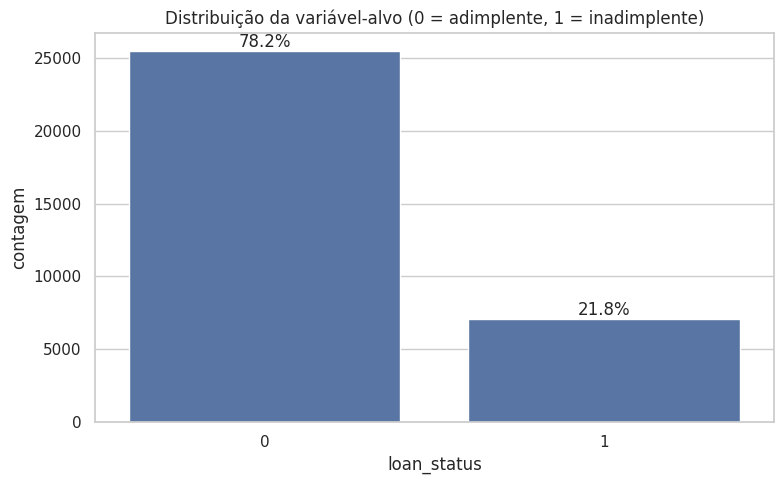

In [9]:
contagem = df["loan_status"].value_counts().sort_index()
proporcao = df["loan_status"].value_counts(normalize=True).sort_index()
print("Contagem:\n", contagem, "\n")
print("Proporção:\n", proporcao.round(4))

ax = sns.countplot(x="loan_status", data=df)
ax.set_title("Distribuição da variável-alvo (0 = adimplente, 1 = inadimplente)")
ax.set_xlabel("loan_status")
ax.set_ylabel("contagem")
for p in ax.patches:
    ax.annotate(f"{p.get_height() / len(df):.1%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 5. Análise univariada — variáveis numéricas

Distribuições e detecção de outliers.

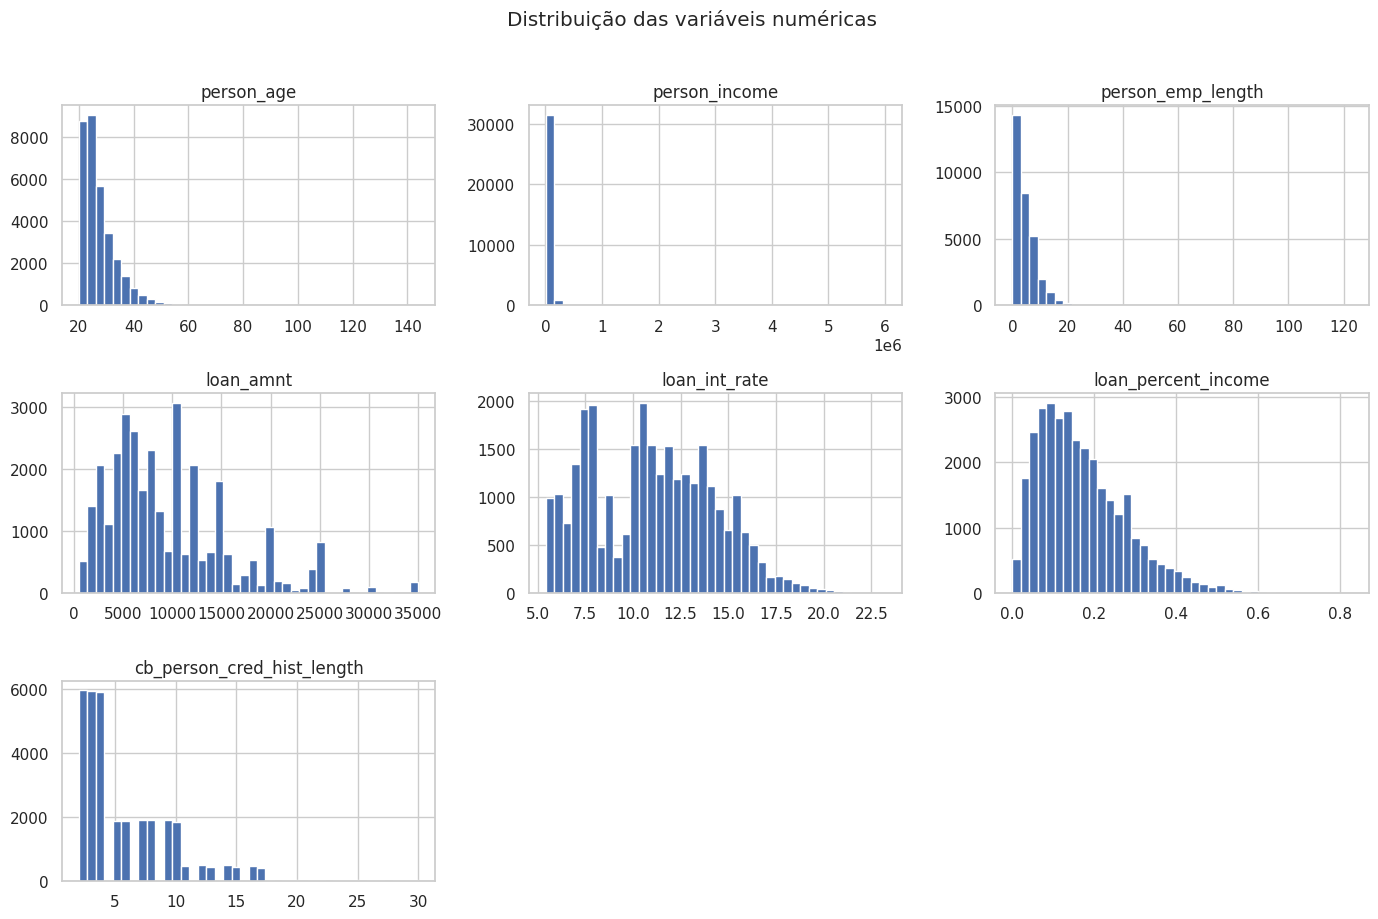

In [10]:
num_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length",
]

# Histogramas
df[num_cols].hist(bins=40, figsize=(14, 9), color="#4c72b0", edgecolor="white")
plt.suptitle("Distribuição das variáveis numéricas", y=1.02)
plt.tight_layout()
plt.show()

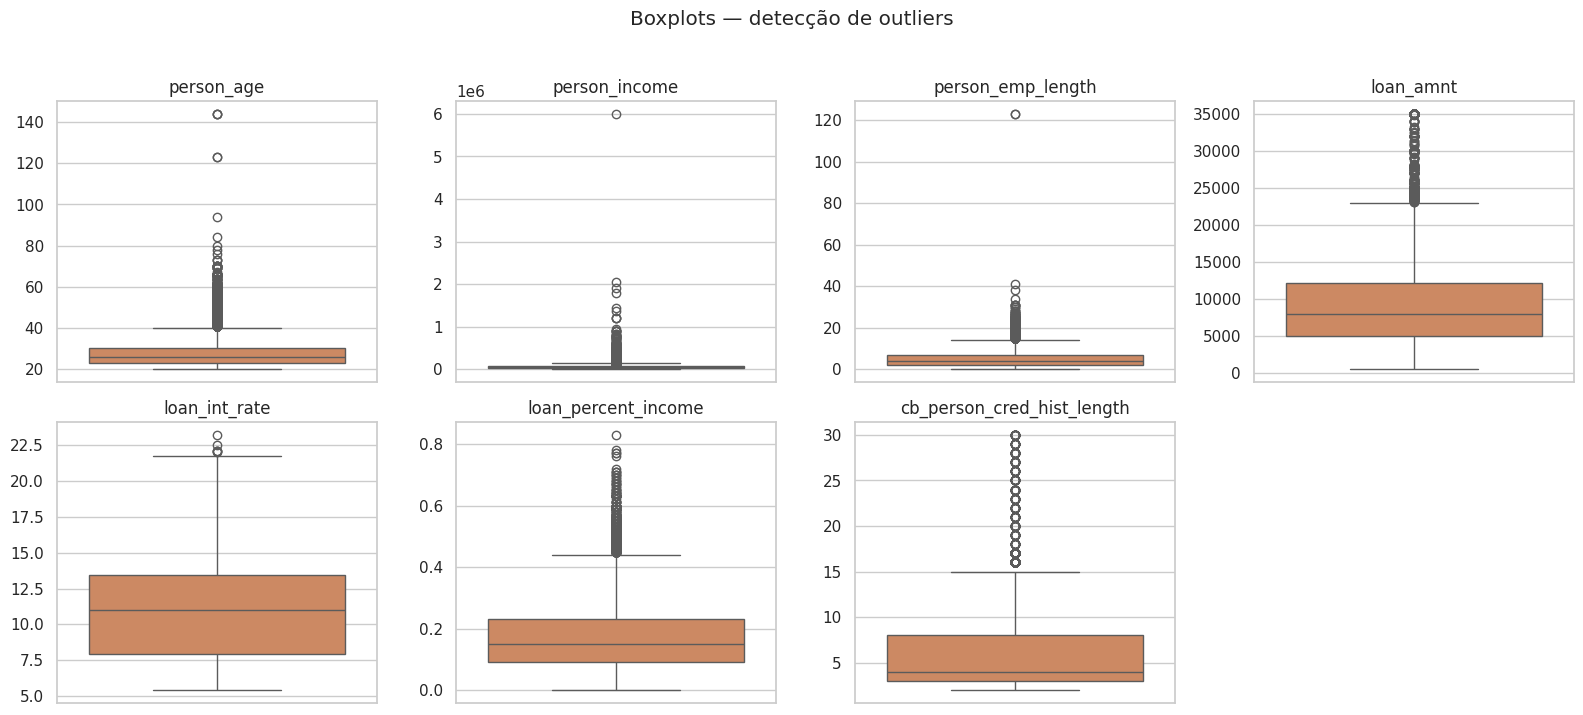

In [11]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#dd8452")
    ax.set_title(col)
    ax.set_ylabel("")
# Esconde eixos não usados
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
plt.suptitle("Boxplots — detecção de outliers", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Outliers evidentes: idade e tempo de emprego impossíveis
print("Idade máxima:", df["person_age"].max())
print("Tempo de emprego máximo:", df["person_emp_length"].max())
print("\nClientes com idade > 100:")
display(df[df["person_age"] > 100][["person_age", "person_emp_length", "person_income"]])
print("Clientes com tempo de emprego > 80 anos:")
display(df[df["person_emp_length"] > 80][["person_age", "person_emp_length", "person_income"]])

Idade máxima: 144
Tempo de emprego máximo: 123.0

Clientes com idade > 100:


,person_age,person_emp_length,person_income
81,144,4.0,250000
183,144,4.0,200000
575,123,2.0,80004
747,123,7.0,78000
32297,144,12.0,6000000


Clientes com tempo de emprego > 80 anos:


,person_age,person_emp_length,person_income
0,22,123.0,59000
210,21,123.0,192000


## 6. Análise univariada — variáveis categóricas

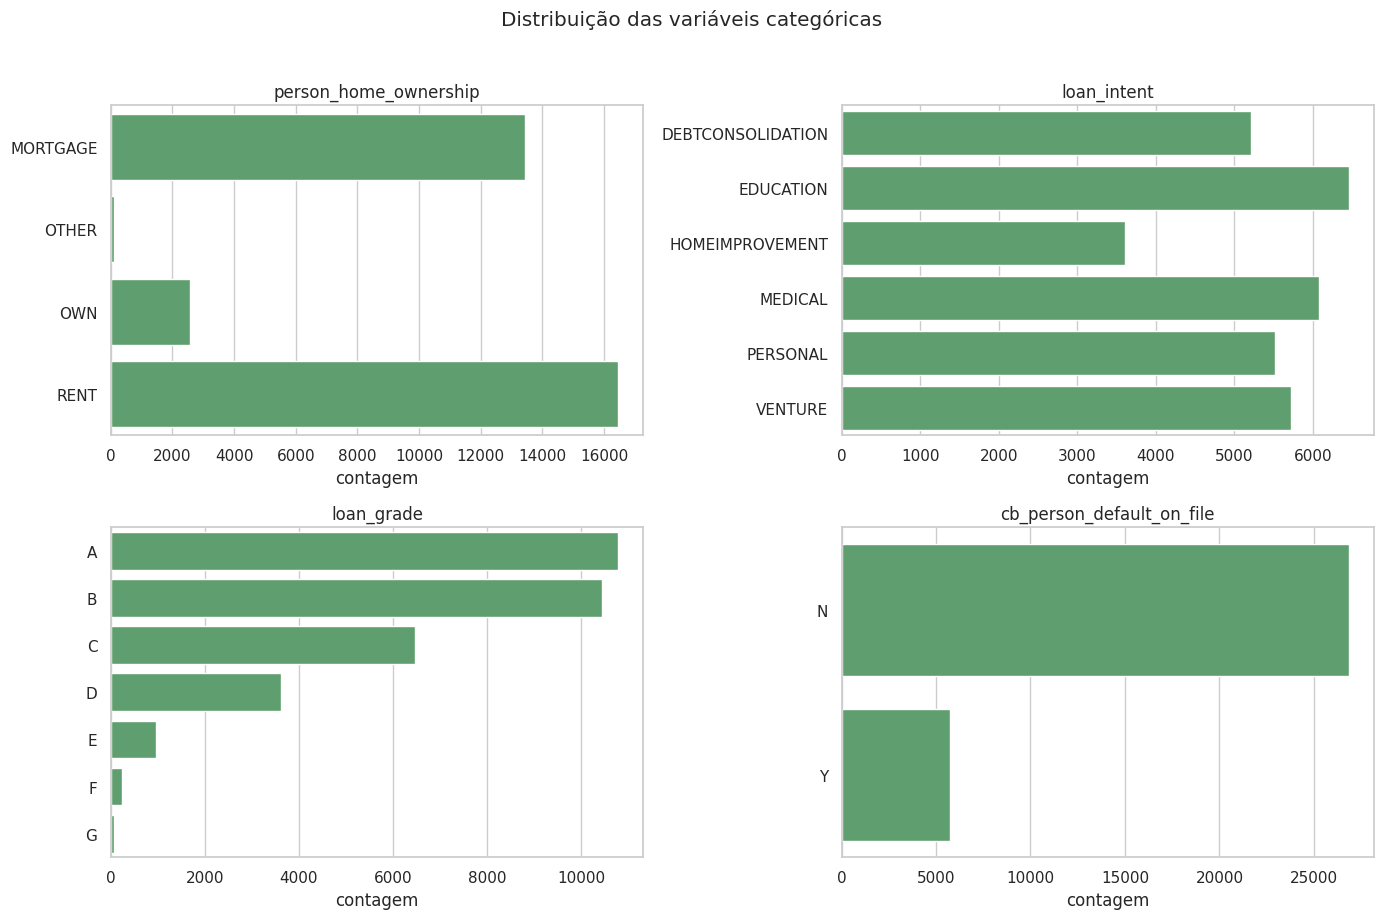

In [13]:
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, cat_cols):
    ordem = sorted(df[col].dropna().unique())
    sns.countplot(y=col, data=df, order=ordem, ax=ax, color="#55a868")
    ax.set_title(col)
    ax.set_xlabel("contagem")
    ax.set_ylabel("")
plt.suptitle("Distribuição das variáveis categóricas", y=1.02)
plt.tight_layout()
plt.show()

## 7. Análise bivariada — relação com a inadimplência

Como cada variável se relaciona com a probabilidade de calote (`loan_status` = 1).

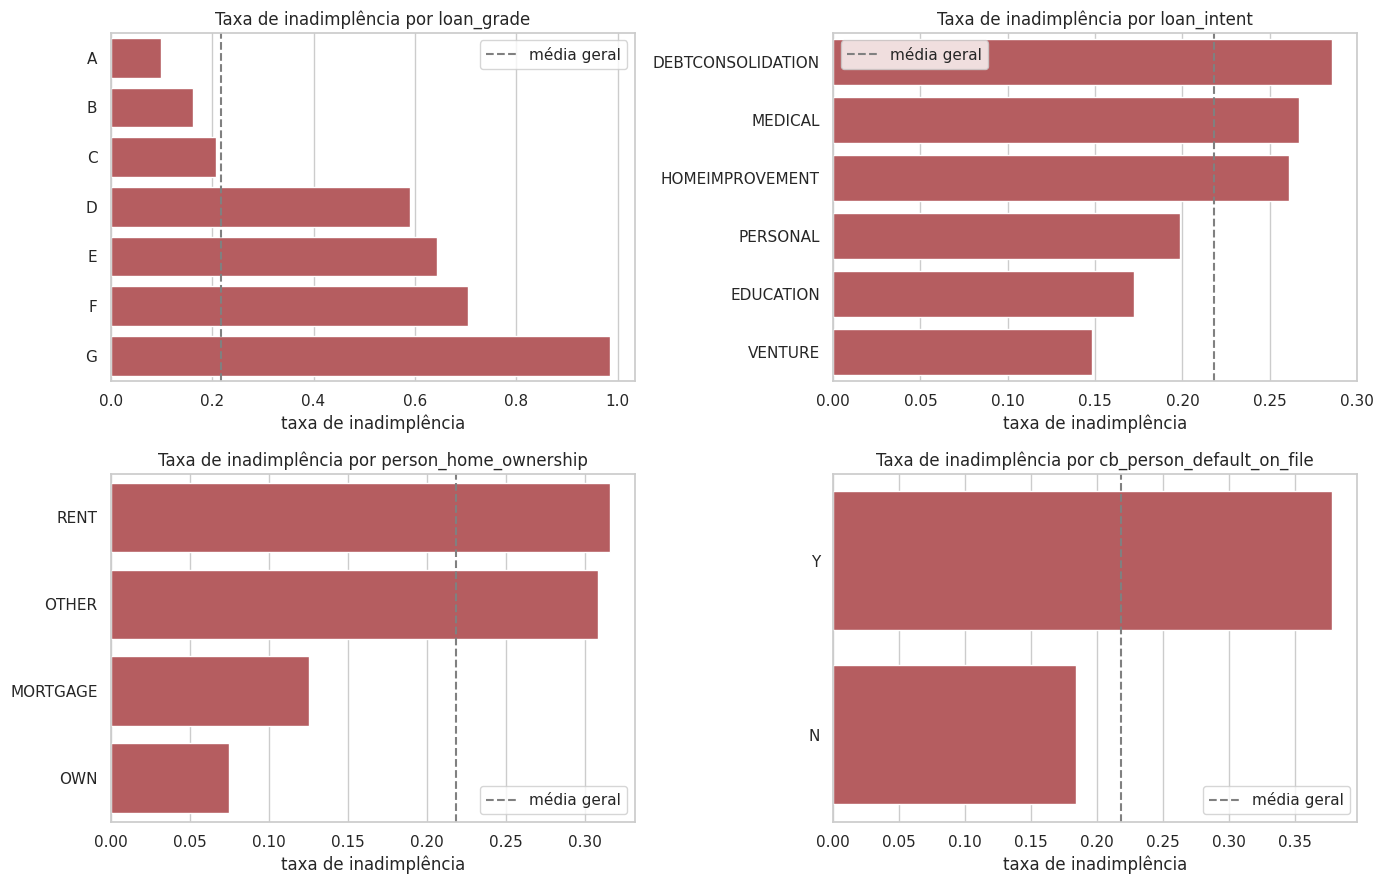

In [14]:
def taxa_inadimplencia_por(col, ordem=None):
    """Taxa média de inadimplência (loan_status) para cada categoria de `col`."""
    taxa = df.groupby(col)["loan_status"].mean()
    if ordem is not None:
        taxa = taxa.reindex(ordem)
    else:
        taxa = taxa.sort_values(ascending=False)
    return taxa

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
configs = [
    ("loan_grade", sorted(df["loan_grade"].dropna().unique())),
    ("loan_intent", None),
    ("person_home_ownership", None),
    ("cb_person_default_on_file", None),
]
for ax, (col, ordem) in zip(axes.flat, configs):
    taxa = taxa_inadimplencia_por(col, ordem)
    sns.barplot(x=taxa.values, y=taxa.index, ax=ax, color="#c44e52")
    ax.axvline(df["loan_status"].mean(), color="gray", linestyle="--", label="média geral")
    ax.set_title(f"Taxa de inadimplência por {col}")
    ax.set_xlabel("taxa de inadimplência")
    ax.set_ylabel("")
    ax.legend()
plt.tight_layout()
plt.show()

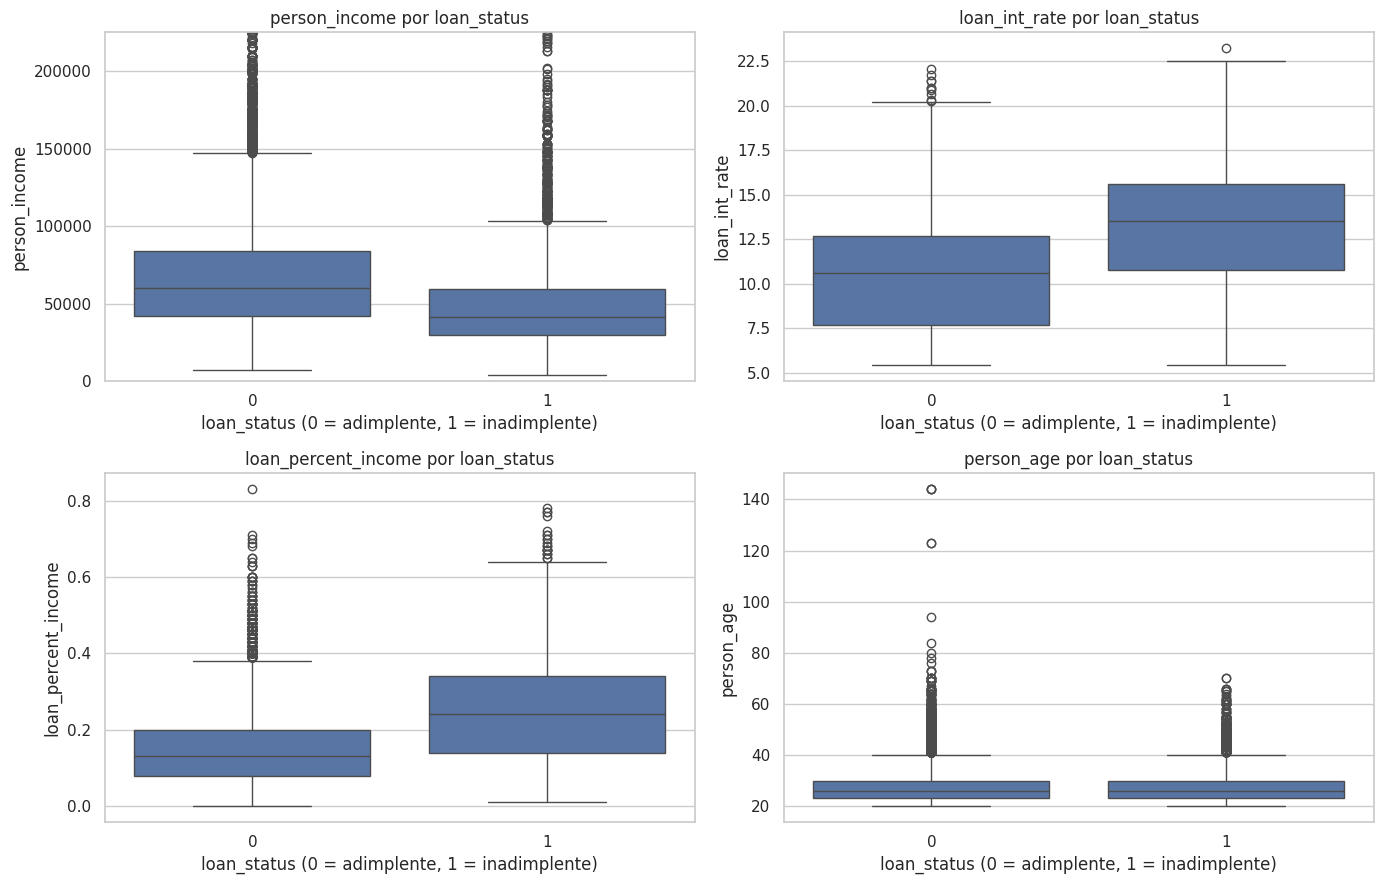

In [15]:
# Variáveis numéricas vs alvo (boxplots por classe)
num_vs_alvo = ["person_income", "loan_int_rate", "loan_percent_income", "person_age"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, num_vs_alvo):
    sns.boxplot(x="loan_status", y=col, data=df, ax=ax)
    ax.set_title(f"{col} por loan_status")
    ax.set_xlabel("loan_status (0 = adimplente, 1 = inadimplente)")
# person_income tem outliers altíssimos: limita o eixo p/ visualização
axes.flat[0].set_ylim(0, df["person_income"].quantile(0.99))
plt.tight_layout()
plt.show()

## 8. Correlações entre variáveis numéricas

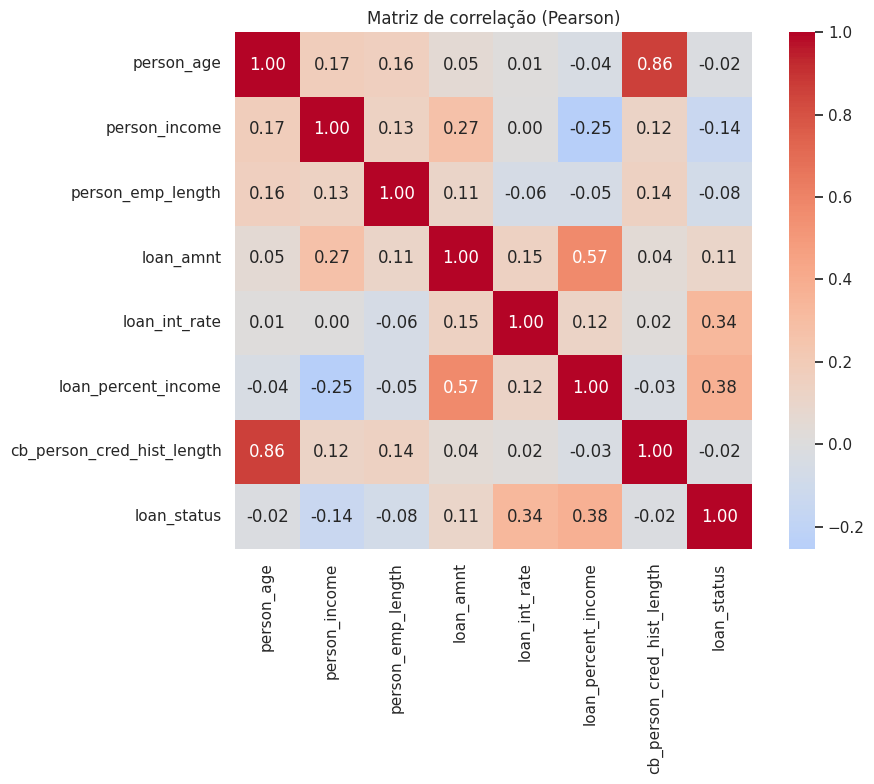

In [16]:
corr = df[num_cols + ["loan_status"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlação (Pearson)")
plt.tight_layout()
plt.show()

## 9. Hipóteses, achados e decisões

### Principais achados
- **Alvo desbalanceado:** apenas ~22% dos registros são inadimplentes → acurácia isolada engana; usar **ROC-AUC, recall, F1 e matriz de confusão**, e tratar o desbalanceamento (class_weight / SMOTE).
- **Valores ausentes:** concentrados em `loan_int_rate` e `person_emp_length` → necessário imputar (ex.: mediana, ou mediana por grupo).
- **Outliers impossíveis:** `person_age` com valores > 100 e `person_emp_length` > 80 anos → erros de digitação; remover/limitar essas linhas.
- **`loan_grade` é forte preditor:** a taxa de inadimplência cresce de forma clara de A → G.
- **Histórico de calote (`cb_person_default_on_file` = Y)** está associado a inadimplência maior.
- **Taxa de juros (`loan_int_rate`) e `loan_percent_income`** tendem a ser maiores entre inadimplentes.

### Hipóteses para a modelagem
1. Quanto pior a `loan_grade` e maior a taxa de juros, maior o risco de calote.
2. Comprometimento de renda alto (`loan_percent_income`) aumenta a inadimplência.
3. Renda mais baixa está associada a maior risco.

### Decisões para a etapa de limpeza (`02_preprocessing`)
- Remover/limitar outliers de `person_age` e `person_emp_length`.
- Imputar ausentes de `loan_int_rate` e `person_emp_length`.
- Remover duplicatas (se houver).
- Codificar categóricas: ordinal para `loan_grade`/`cb_person_default_on_file`, one-hot para `loan_intent` e `person_home_ownership`.
- Padronizar numéricas para modelos sensíveis à escala.
- Salvar o resultado em `data/processed/credit_clean.csv` (contrato com o time).